# Spectral-chord diagnostics: unbounded vs loose vs tight

Compares per-step optimizer diagnostics across three trust-region rules at
their best-final-loss lrs:
- **unbounded coupled** (Frobenius rescale): `adam-polar-product-lora-coupled`
- **loose chord** (Spectron's ρ=η/(s+1)): `adam-polar-product-lora-coupled-spectral-chord`
- **tight chord** (exact root ρ=(-s+√(s²+4η))/2): `adam-polar-product-lora-coupled-spectral-chord-tight`

Faceted by rank r ∈ {16, 32, 64, 128, 256}. Per-cell best lr resolved at load time.

Source data: completed sweeps. Tight: spectral_chord_tight_rsweep_4k (r ∈ {16,32,64,128,256} × lr ∈ {3e-3, 1e-2, 3e-2}, 15/15 cells finished 2026-05-05). Loose: spectral_chord_rsweep_4k. Unbounded: prior 4k r-sweeps with diagnostics. All canonical 4000-step horizon, single seed.

In [80]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import math
import warnings
warnings.simplefilter('ignore')

import numpy as np
import matplotlib.pyplot as plt
from lora_playground.loader import load_runs

## Data load

For each (method, rank) we pick the cell with the lowest final eval_loss across the available lrs, then keep its eval trajectory + optim_step trajectory.

All methods cover r ∈ {16, 32, 64, 128, 256} at the canonical 4000-step horizon; loaders return `None` only if a (method, rank) cell is genuinely absent (downstream plots skip those).

In [82]:
METHODS = {
    'unbounded coupled': 'adam-polar-product-lora-coupled',
    'loose chord':       'adam-polar-product-lora-coupled-spectral-chord',
    'tight chord':       'adam-polar-product-lora-coupled-spectral-chord-tight',
}
RANKS = [16, 32, 64, 128, 256]

# Distinct hues for clear three-way contrast (overrides the chord-family
# burnt-orange shades in plot_utils.OPTIM_COLORS, which are too close to
# distinguish at line-thickness when overlaid).
METHOD_COLOR = {
    'unbounded coupled': '#5d342c',  # dark brown — Frobenius rescale (the prior baseline)
    'loose chord':       '#1f77b4',  # blue — Spectron rule ρ=η/(s+1)
    'tight chord':       '#d62728',  # red — exact-root ρ=(-s+√(s²+4η))/2
}

def best_cell(method_name, r):
    """Pick the cell with the lowest FINAL eval_loss across all lrs available."""
    runs = load_runs(
        where={'optimizer': METHODS[method_name], 'max_steps': 4000, 'lora_r': r},
        warn_cross_commit=False,
    )
    runs = [(c, e) for c, e in runs if e]
    if not runs:
        return None
    cfg, evs = min(runs, key=lambda r: r[1][-1]['eval_loss'])
    return {
        'cfg': cfg, 'evs': evs,
        'diag': cfg.get('_optim_steps', []),
        'lr': cfg.get('lr'),
        'final_loss': evs[-1]['eval_loss'],
        'final_step': evs[-1]['step'],
    }

DATA = {(m, r): best_cell(m, r) for m in METHODS for r in RANKS}

# Audit: print what we got
print(f"{'method':>22s} {'r':>4} {'lr':>7} {'final_step':>11} {'final_loss':>10} {'n_diag':>7}")
for (m, r), d in DATA.items():
    if d is None:
        print(f"{m:>22s} {r:>4} {'--':>7} {'--':>11} {'--':>10} {'--':>7}")
    else:
        print(f"{m:>22s} {r:>4} {d['lr']:>7.0e} {d['final_step']:>11} {d['final_loss']:>10.4f} {len(d['diag']):>7}")


# AdamW baseline (per-rank best lr). Has eval data only — no optim_step
# diagnostics. Used on the loss plot below for reference; silently skipped
# by the diagnostic plots since len(diag) == 0.
def best_adamw(r):
    runs = load_runs(where={'optimizer': 'adamw', 'max_steps': 4000, 'lora_r': r}, warn_cross_commit=False)
    runs = [(c, e) for c, e in runs if e]
    if not runs:
        return None
    cfg, evs = min(runs, key=lambda r: r[1][-1]['eval_loss'])
    return {'cfg': cfg, 'evs': evs, 'lr': cfg.get('lr'), 'final_loss': evs[-1]['eval_loss'], 'final_step': evs[-1]['step']}

ADAMW = {r: best_adamw(r) for r in RANKS}
print()
print(f"AdamW baselines (per-rank best lr):")
for r in RANKS:
    a = ADAMW.get(r)
    if a:
        print(f"  r={r:>3} lr={a['lr']:.0e} step={a['final_step']} final_loss={a['final_loss']:.4f}")
    else:
        print(f"  r={r:>3} no AdamW data")


                method    r      lr  final_step final_loss  n_diag
     unbounded coupled   16   3e-04        4000     0.7319      50
     unbounded coupled   32   3e-04        4000     0.7212      50
     unbounded coupled   64   3e-04        4000     0.7172      50
     unbounded coupled  128   3e-04        4000     0.7197      50
     unbounded coupled  256   1e-04        4000     0.7136      50
           loose chord   16   1e-02        4000     0.7343      50
           loose chord   32   1e-02        4000     0.7249      50
           loose chord   64   1e-02        4000     0.7199      50
           loose chord  128   1e-02        4000     0.7151      50
           loose chord  256   3e-02        4000     0.7084      50
           tight chord   16   1e-02        4000     0.7319      50
           tight chord   32   1e-02        4000     0.7214      50
           tight chord   64   1e-02        4000     0.7159      50
           tight chord  128   1e-02        4000     0.7104    

## Plot helpers

In [83]:
def diag_trajectory(d, key, transform=None):
    """Return (steps, values) from a run's diag list, applying optional transform."""
    if d is None or not d['diag']:
        return np.array([]), np.array([])
    steps = np.array([r['step'] for r in d['diag']])
    vals = np.array([r.get(key, np.nan) for r in d['diag']], dtype=float)
    if transform is not None:
        vals = transform(vals)
    return steps, vals

def loss_trajectory(d):
    if d is None:
        return np.array([]), np.array([])
    return (np.array([e['step'] for e in d['evs']]),
            np.array([e['eval_loss'] for e in d['evs']]))

def faceted_plot(plot_fn, title, ylabel, ranks=RANKS, ylog=False,
                 figsize=None, sharey=True):
    """Per-rank panels with a single figure-level method-only legend.

    Per-cell best lr is resolved at load time and can differ across r;
    the convention is documented on the eval-loss plot above and in the
    audit table at the top of the data-load cell.
    """
    n = len(ranks)
    fig, axes = plt.subplots(1, n, figsize=figsize or (4*n, 3.5),
                              sharey=sharey, sharex=True)
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, ranks):
        for m in METHODS:
            d = DATA.get((m, r))
            if d is None:
                continue
            plot_fn(ax, d, m)
        ax.set_title(f'r={r}', fontsize=11)
        ax.set_xlabel('step')
        ax.grid(alpha=0.3)
        if ylog:
            ax.set_yscale('log')
    axes[0].set_ylabel(ylabel)
    handles, labels = axes[-1].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=len(METHODS),
                   bbox_to_anchor=(0.5, 1.04), frameon=False)
    fig.suptitle(title, y=1.14, fontsize=12)
    plt.tight_layout()
    plt.show()

## Eval loss trajectory

Sets the stage. Lower is better.

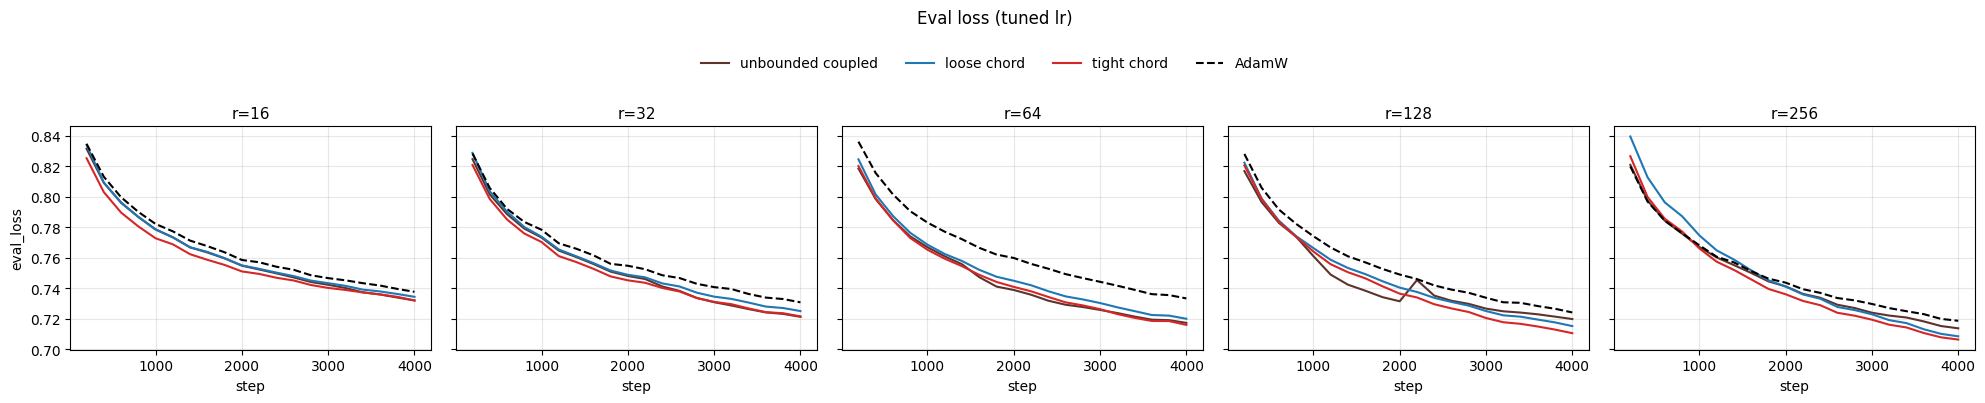

In [84]:
def _plot_loss(ax, d, m):
    s, v = loss_trajectory(d)
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

def _plot_with_adamw(plot_fn, title, ylabel, **kw):
    # Same as faceted_plot but overlays AdamW (black dashed) on every
    # facet. Method-only legend labels — per-cell lrs differ across r and
    # are visible in the audit table.
    n = len(RANKS)
    fig, axes = plt.subplots(1, n, figsize=kw.get('figsize') or (4*n, 3.5),
                              sharey=kw.get('sharey', True), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, RANKS):
        for m in METHODS:
            d = DATA.get((m, r))
            if d is None:
                continue
            plot_fn(ax, d, m)
        a = ADAMW.get(r)
        if a is not None:
            ax.plot([e['step'] for e in a['evs']], [e['eval_loss'] for e in a['evs']],
                    color='black', label='AdamW', lw=1.5, ls='--')
        ax.set_title(f'r={r}', fontsize=11)
        ax.set_xlabel('step')
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)
    handles, labels = axes[-1].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=len(METHODS)+1,
                   bbox_to_anchor=(0.5, 1.04), frameon=False)
    fig.suptitle(title, y=1.14, fontsize=12)
    plt.tight_layout()
    plt.show()

_plot_with_adamw(_plot_loss, 'Eval loss (tuned lr)', 'eval_loss', sharey=True)


## lr sensitivity vs rank

Final eval_loss as a function of lr, one curve per rank.

If the optimizer has a **rank-stable optimum**, the curves' minima line up at
roughly the same lr — meaning lr transfers across r. If the minimum drifts
with r (as is typical for AdamW on LoRA), tuning lr per r is necessary.

Hypothesis: tight chord's spectral trust region pins the per-step magnitude
in a r-invariant way, so the optimum lr is stable. AdamW should drift.

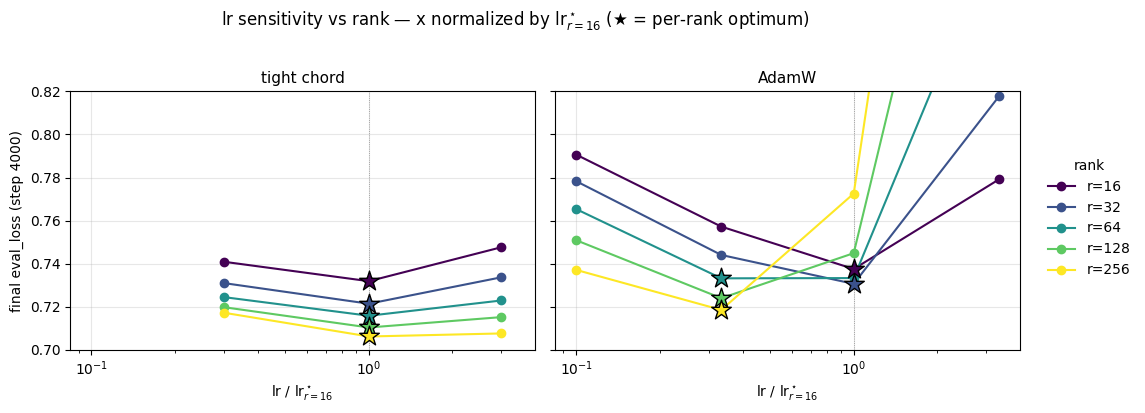

In [85]:
from collections import defaultdict
import matplotlib.cm as cm

def lr_curve(optimizer):
    """For one optimizer, return {r: [(lr, final_loss), ...]} sorted by lr.
    Picks the best (lowest final_loss) entry per (r, lr) cell to dedup."""
    runs = load_runs(where={'optimizer': optimizer, 'max_steps': 4000},
                     warn_cross_commit=False)
    by_cell = {}
    for cfg, evs in runs:
        if not evs:
            continue
        key = (cfg['lora_r'], cfg['lr'])
        fl = evs[-1]['eval_loss']
        if key not in by_cell or fl < by_cell[key]:
            by_cell[key] = fl
    by_r = defaultdict(list)
    for (r, lr), fl in by_cell.items():
        by_r[r].append((lr, fl))
    for r in by_r:
        by_r[r].sort()
    return dict(by_r)

LR_PANELS = [
    ('tight chord', 'adam-polar-product-lora-coupled-spectral-chord-tight'),
    ('AdamW',       'adamw'),
]

# Normalize x by the r=16 optimum (the SAME reference for every r). This
# preserves the per-rank optimum drift: a stable optimizer has all stars
# stacked at x=1; a drifting one (AdamW) has stars walking left as r
# grows. Per-rank normalization would have hidden this by definition.
#
# Shared y-clip: AdamW's lr=1e-3 cells diverge to loss > 1 at high r;
# without clipping the rest of the data squishes. Off-axis points exit
# through the top edge and are not annotated.
YLIM = (0.700, 0.820)
REF_R = 16

fig, axes = plt.subplots(1, len(LR_PANELS), figsize=(5.2*len(LR_PANELS), 4),
                         sharey=True, sharex=True)
cmap = cm.get_cmap('viridis')
norm = plt.Normalize(vmin=np.log2(min(RANKS)), vmax=np.log2(max(RANKS)))

for ax, (label, opt) in zip(axes, LR_PANELS):
    data = lr_curve(opt)
    lr_ref = min(data[REF_R], key=lambda x: x[1])[0]  # lr* at r=REF_R
    for r in RANKS:
        if r not in data:
            continue
        lrs = np.array([lr for lr, _ in data[r]])
        fls = np.array([fl for _, fl in data[r]])
        lr_star, fl_star = min(data[r], key=lambda x: x[1])
        x = lrs / lr_ref  # SAME reference for every r → drift visible
        color = cmap(norm(np.log2(r)))
        ax.plot(x, fls, marker='o', color=color, label=f'r={r}', lw=1.5)
        ax.scatter([lr_star / lr_ref], [fl_star], color=color, marker='*',
                   s=220, edgecolor='black', linewidth=1.0, zorder=5)
    ax.set_xscale('log')
    ax.set_xlabel(rf'lr / lr$^\star_{{r={REF_R}}}$')
    ax.axvline(1.0, color='gray', lw=0.6, ls=':', zorder=0)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(*YLIM)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('final eval_loss (step 4000)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False, title='rank')
fig.suptitle(rf'lr sensitivity vs rank — x normalized by lr$^\star_{{r={REF_R}}}$ '
             '(★ = per-rank optimum)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## σ_max(A) and σ_max(B) trajectories

Median across LoRA pairs. SA / SB are the Gram matrices, so σ_max(A) = √SA_max_median.

Hypothesis under test: **unbounded grows σ_A faster than loose/tight; σ_B agrees across methods.**

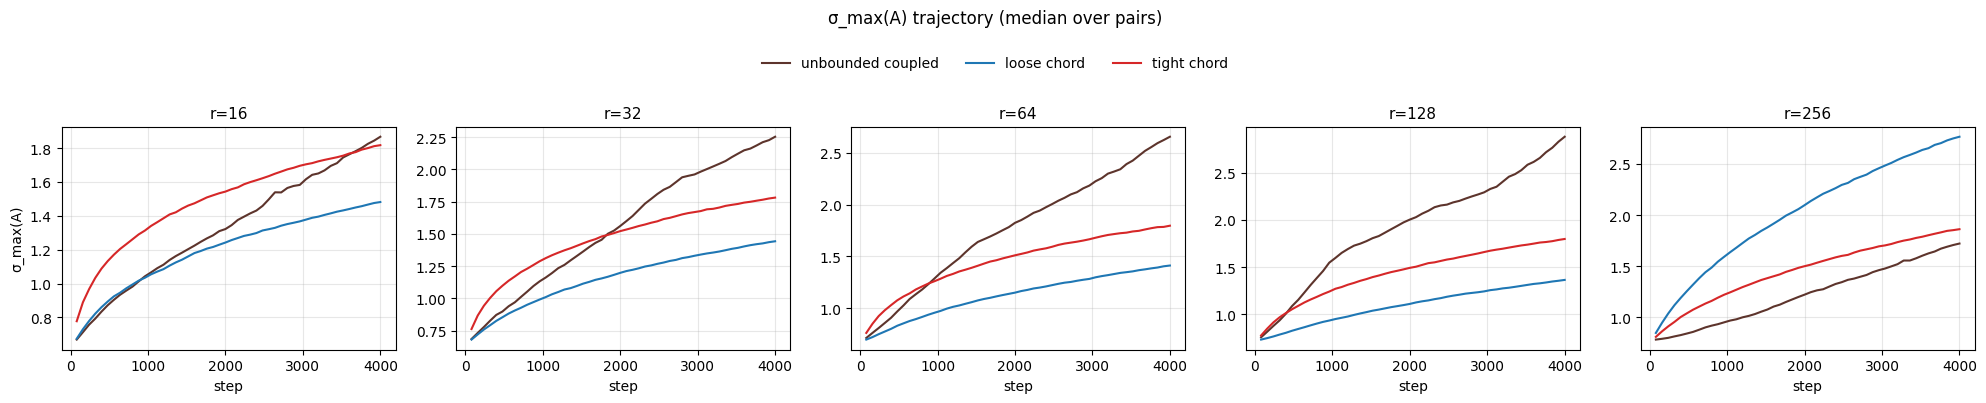

In [86]:
def _plot_sA(ax, d, m):
    s, v = diag_trajectory(d, 'SA_max_median', transform=np.sqrt)
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_sA, 'σ_max(A) trajectory (median over pairs)', 'σ_max(A)', sharey=False)

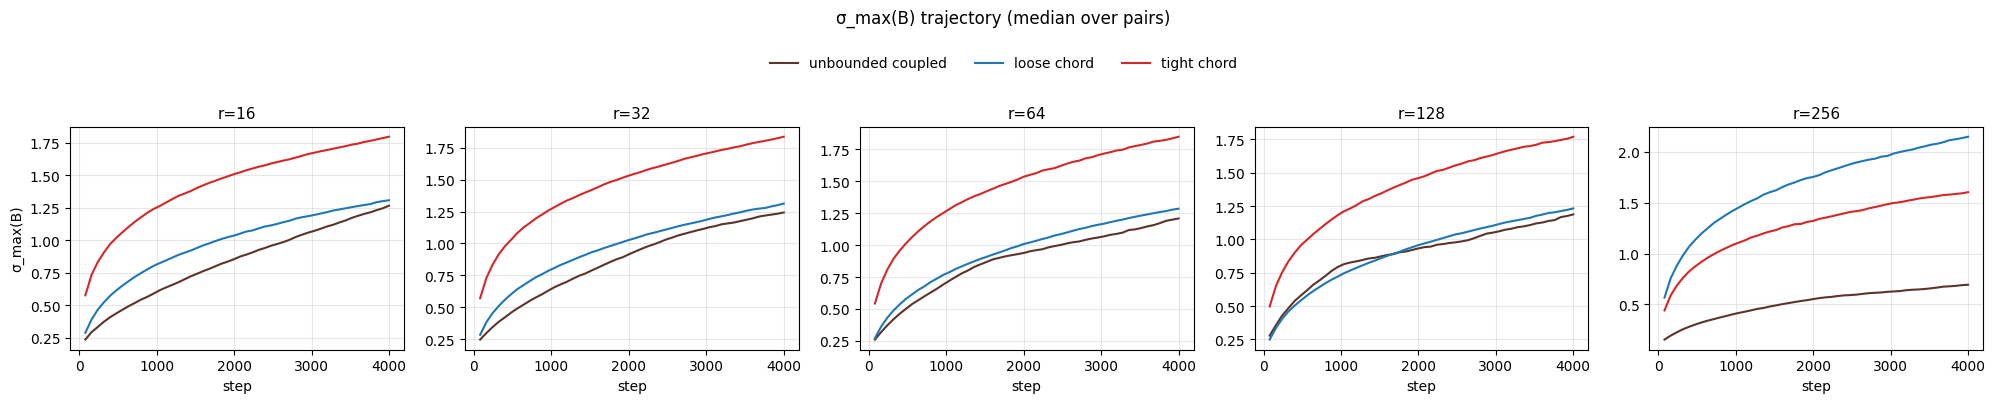

In [87]:
def _plot_sB(ax, d, m):
    s, v = diag_trajectory(d, 'SB_max_median', transform=np.sqrt)
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_sB, 'σ_max(B) trajectory (median over pairs)', 'σ_max(B)', sharey=False)

## Stable rank of A, B

Stable rank = ‖M‖_F² / ‖M‖_op². Higher = singular spectrum spread across more directions; lower = concentrated.

If loose flattens the rank of A-updates relative to unbounded, A's stable rank should be **higher** under loose.

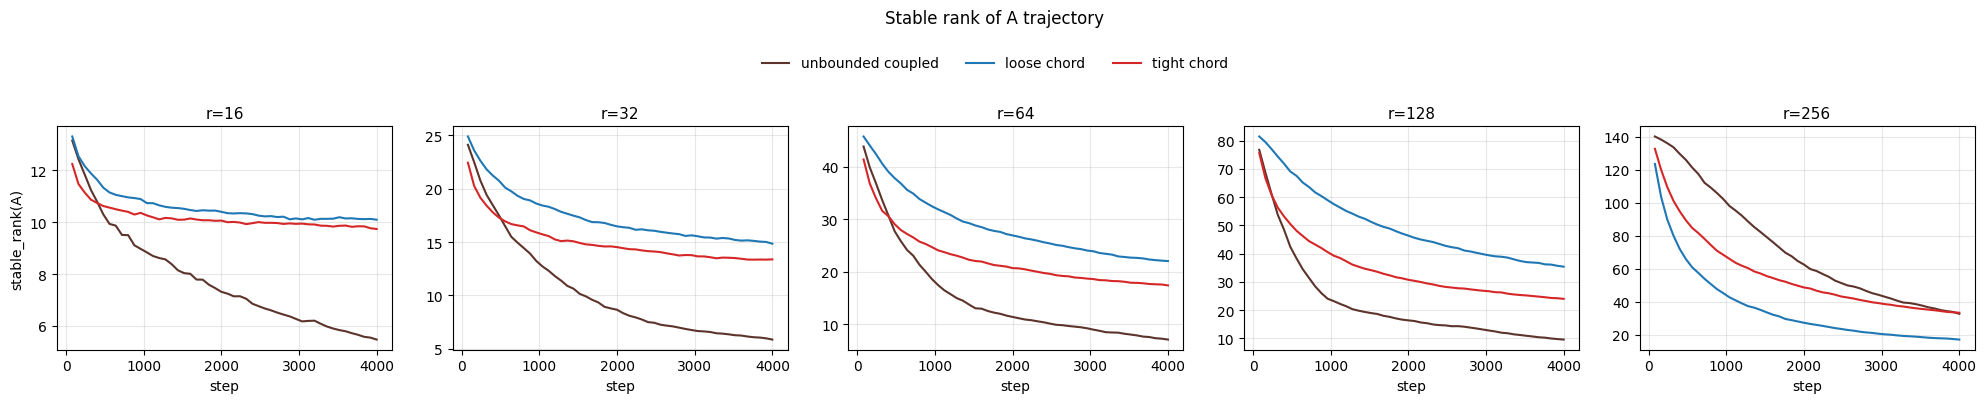

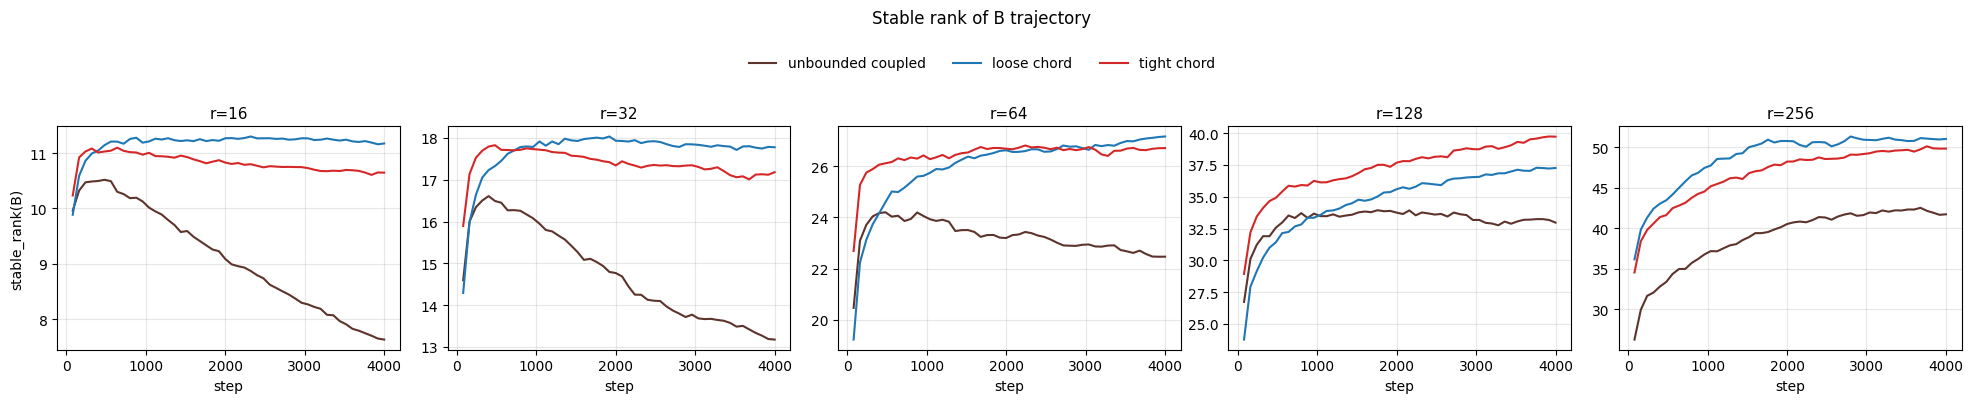

In [88]:
def _plot_srA(ax, d, m):
    s, v = diag_trajectory(d, 'stable_rank_A_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_srA, 'Stable rank of A trajectory', 'stable_rank(A)', sharey=False)

def _plot_srB(ax, d, m):
    s, v = diag_trajectory(d, 'stable_rank_B_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_srB, 'Stable rank of B trajectory', 'stable_rank(B)', sharey=False)

## Per-step update magnitudes

`norm_dA`, `norm_dB`: Frobenius norms of the actual ΔA, ΔB applied each step.

If trust-region rules differ in how they spread budget, `norm_d*` should differ even when σ_A, σ_B converge.

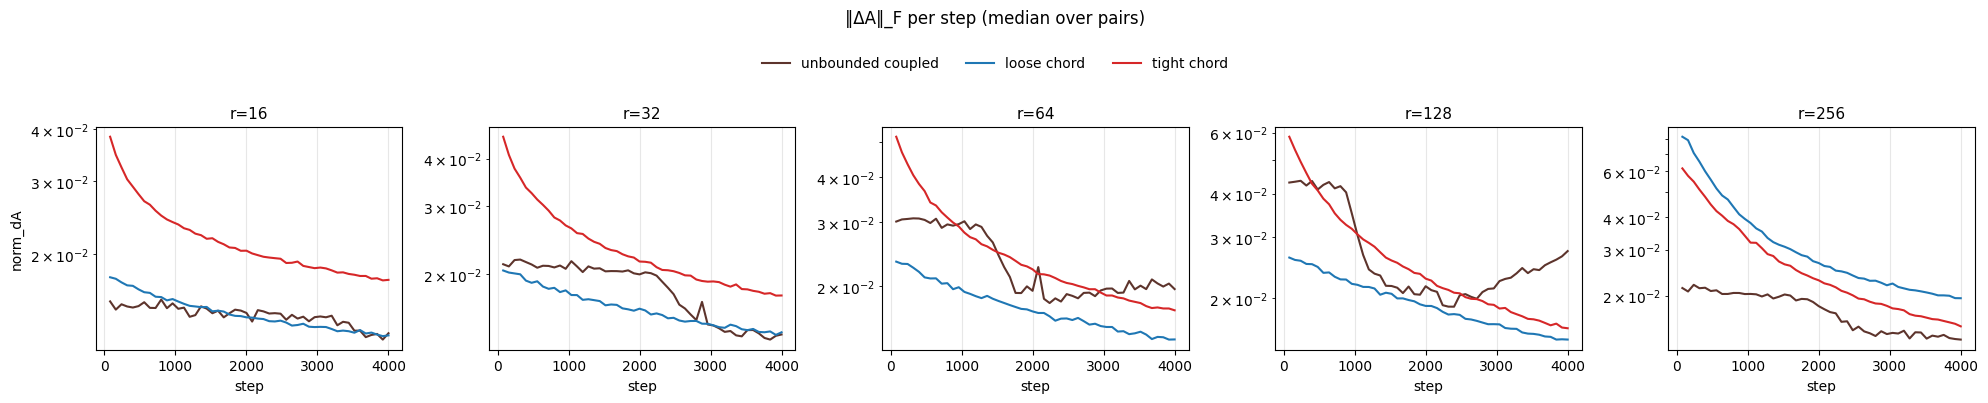

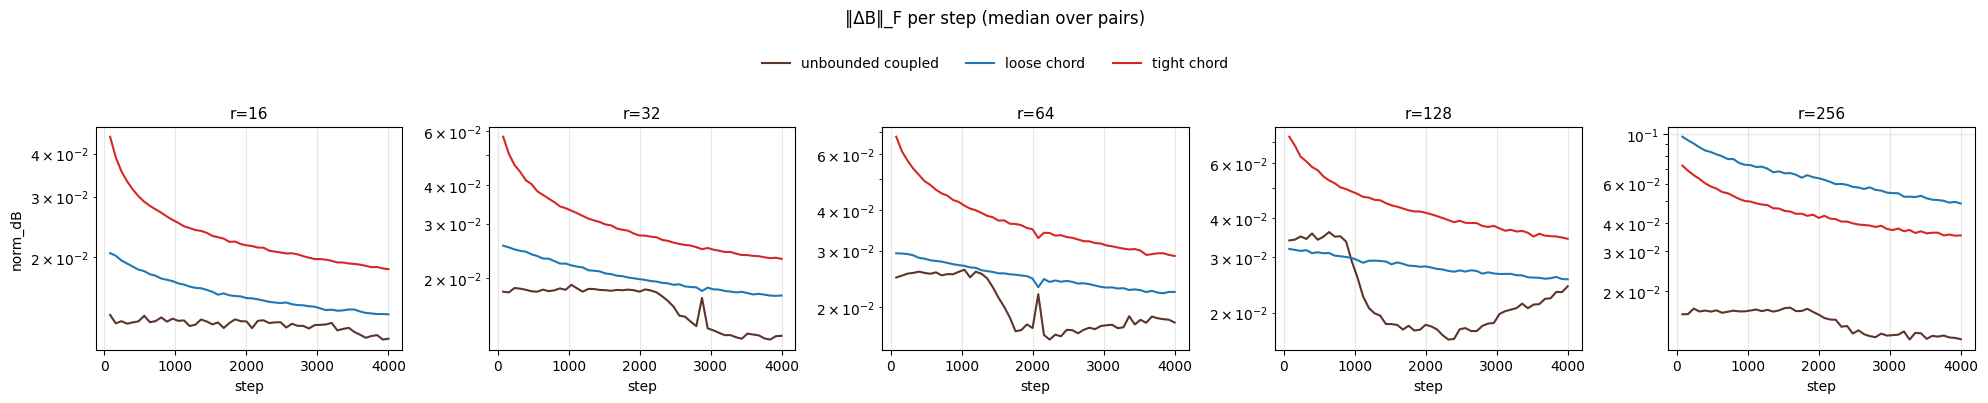

In [89]:
def _plot_dA(ax, d, m):
    s, v = diag_trajectory(d, 'norm_dA_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_dA, '‖ΔA‖_F per step (median over pairs)', 'norm_dA', sharey=False, ylog=True)

def _plot_dB(ax, d, m):
    s, v = diag_trajectory(d, 'norm_dB_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_dB, '‖ΔB‖_F per step (median over pairs)', 'norm_dB', sharey=False, ylog=True)

## Spectral concentration of unwhitened updates

`xunc_A_smax_over_tau_equal`: ratio of σ_max(unwhitened-A-update) to its equal-tau magnitude. 
- ≈ 1: update is spectrally flat — operator-norm clip and Frobenius rescale agree.
- ≫ 1: update is concentrated — operator-norm clip bites hard relative to Frobenius.

If unbounded vs loose differ on this, it's the direct mechanism behind their different σ_A trajectories.

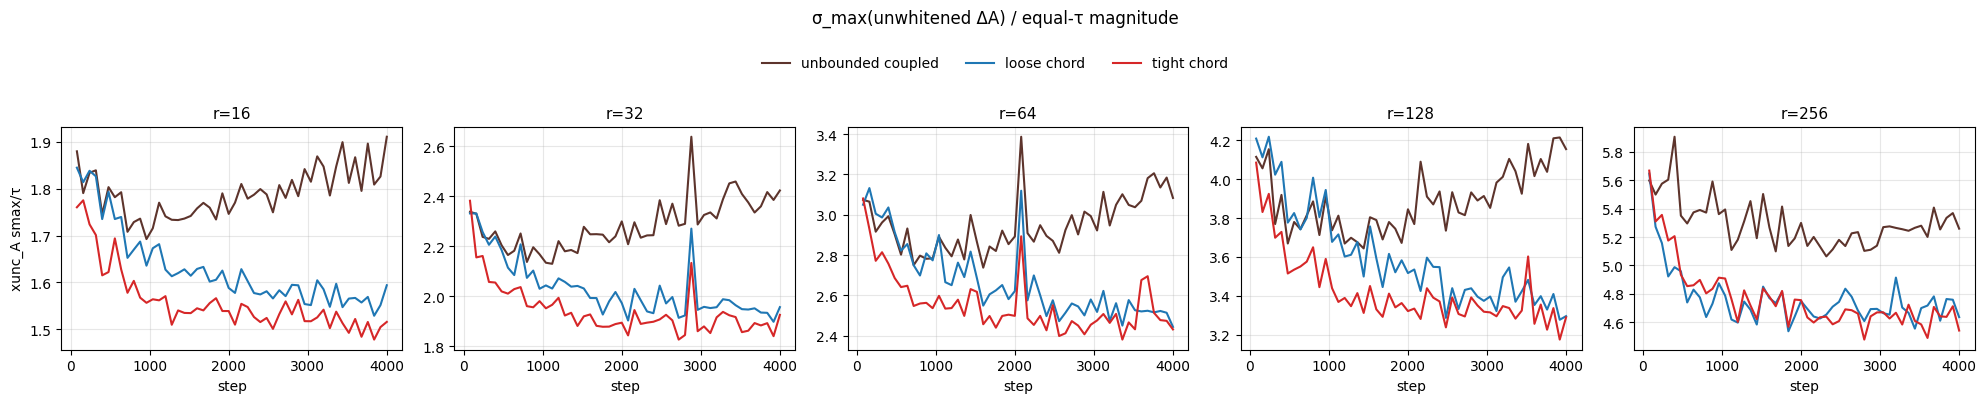

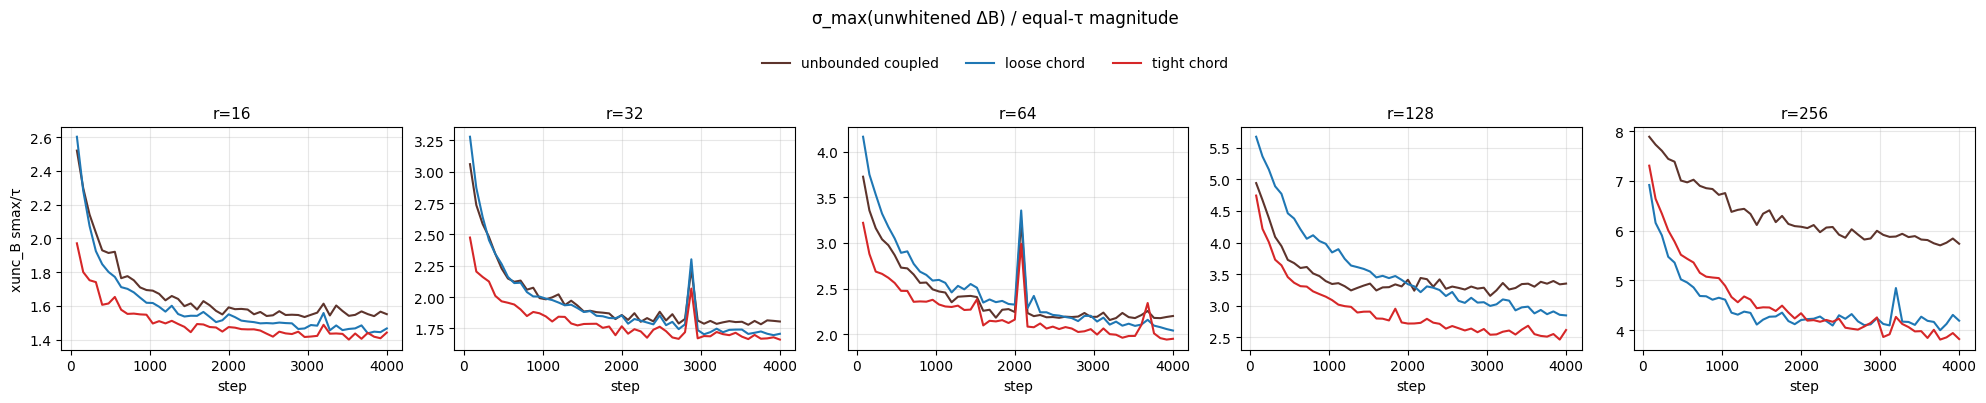

In [90]:
def _plot_xunc_A(ax, d, m):
    s, v = diag_trajectory(d, 'xunc_A_smax_over_tau_equal_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_xunc_A, 'σ_max(unwhitened ΔA) / equal-τ magnitude', 'xunc_A smax/τ', sharey=False)

def _plot_xunc_B(ax, d, m):
    s, v = diag_trajectory(d, 'xunc_B_smax_over_tau_equal_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_xunc_B, 'σ_max(unwhitened ΔB) / equal-τ magnitude', 'xunc_B smax/τ', sharey=False)

## Participation ratio of unwhitened updates

`xunc_A_participation`: effective number of singular values active in the unwhitened A-update. Higher = update spread across more directions.

If loose's lower σ_A growth comes from spreading the budget, A's participation should be **higher** under loose.

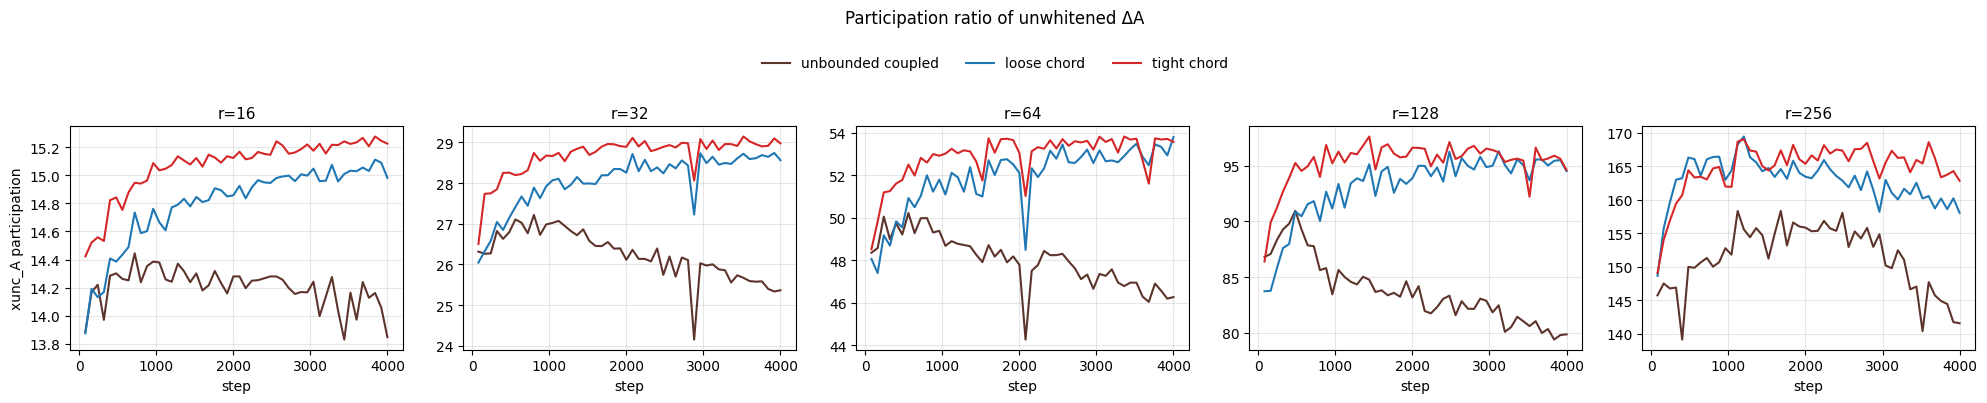

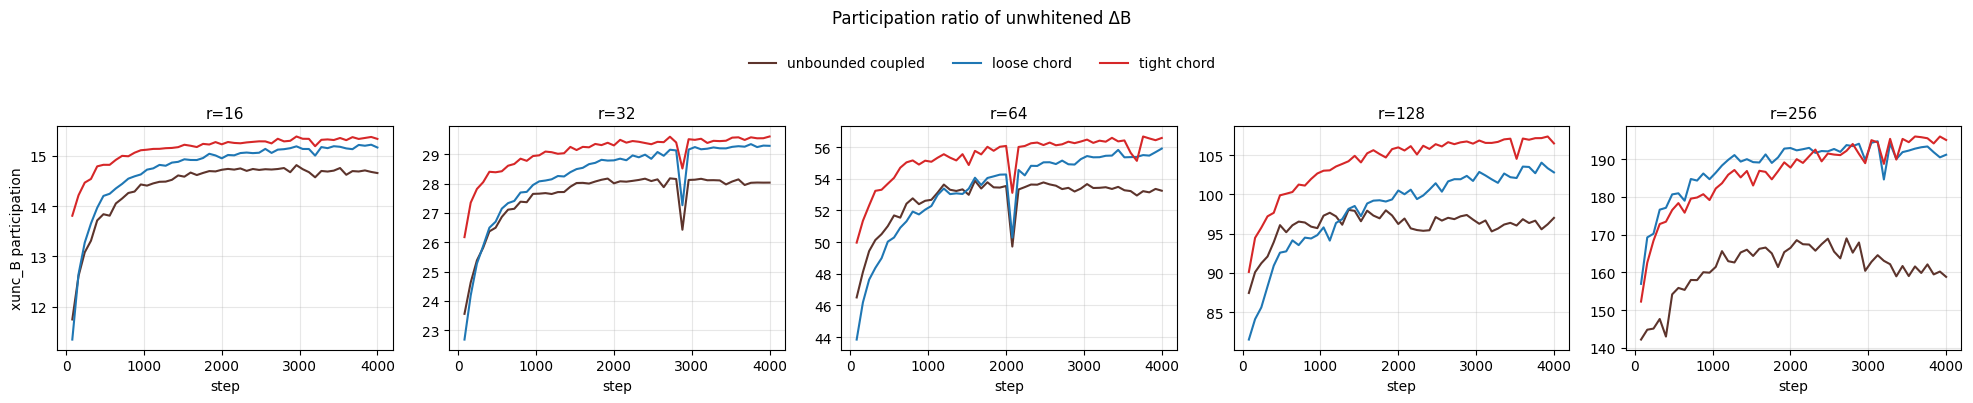

In [91]:
def _plot_part_A(ax, d, m):
    s, v = diag_trajectory(d, 'xunc_A_participation_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_part_A, 'Participation ratio of unwhitened ΔA', 'xunc_A participation', sharey=False)

def _plot_part_B(ax, d, m):
    s, v = diag_trajectory(d, 'xunc_B_participation_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_part_B, 'Participation ratio of unwhitened ΔB', 'xunc_B participation', sharey=False)

## Polar vs clip alignment

`cos_polar_clip_A/B`: cosine between the polar update and the clip update at each step.

= 1: polar = clip; the rescale rule doesn't change direction. Anisotropy in the trust-region rule manifests when this < 1.

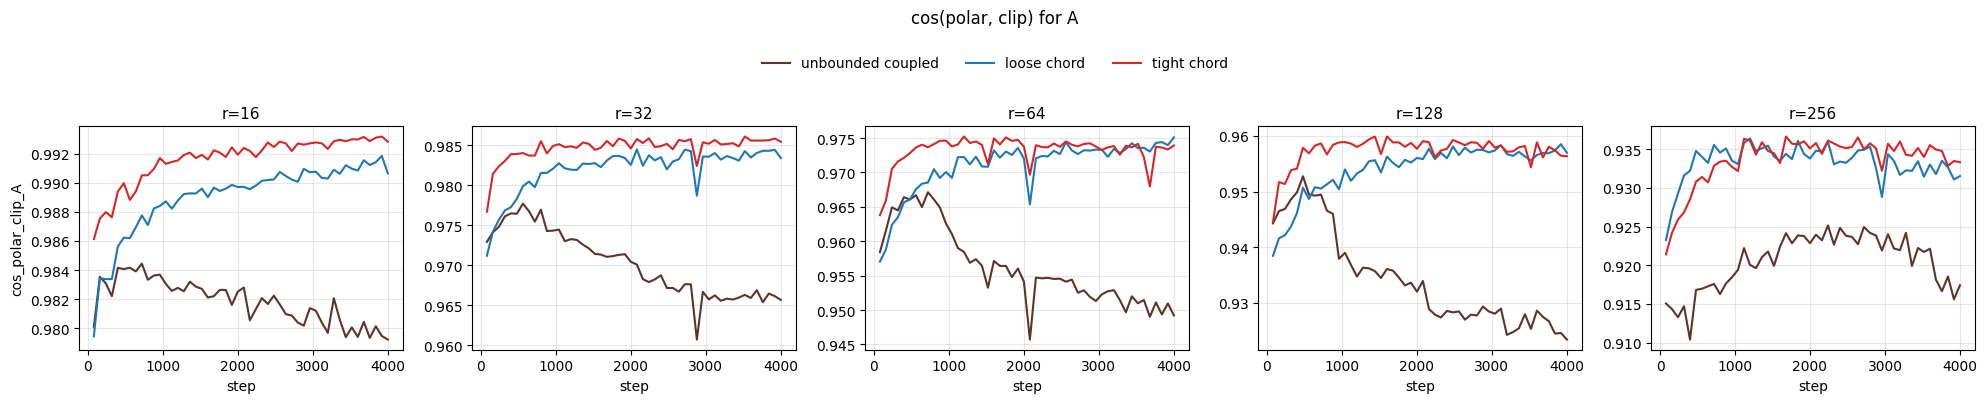

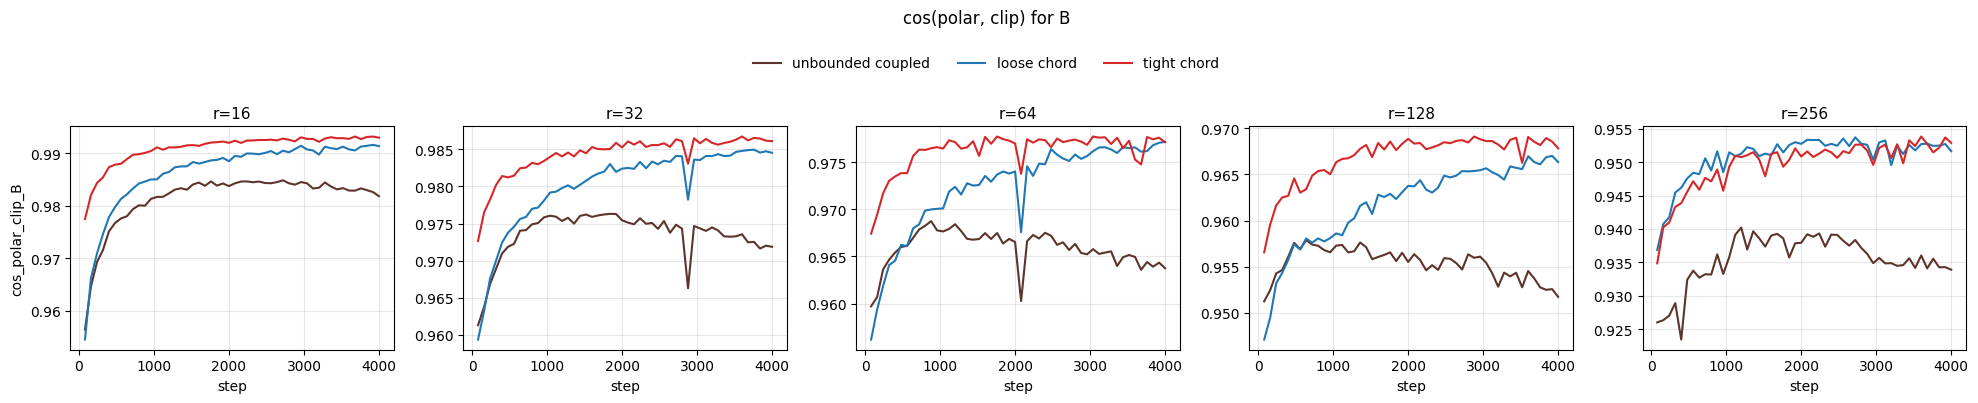

In [92]:
def _plot_pcA(ax, d, m):
    s, v = diag_trajectory(d, 'cos_polar_clip_A_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_pcA, 'cos(polar, clip) for A', 'cos_polar_clip_A', sharey=False)

def _plot_pcB(ax, d, m):
    s, v = diag_trajectory(d, 'cos_polar_clip_B_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_pcB, 'cos(polar, clip) for B', 'cos_polar_clip_B', sharey=False)

## ‖A‖_F, ‖B‖_F (norm of the factors themselves)

Cumulative; should grow ~linearly under stable training.

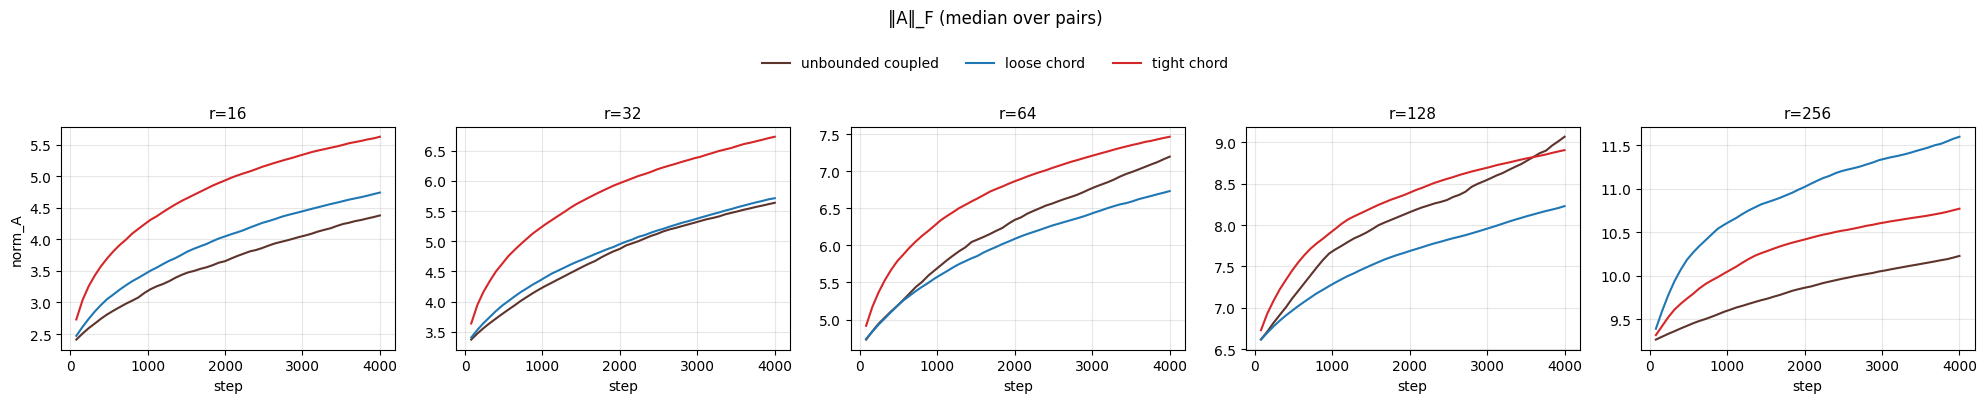

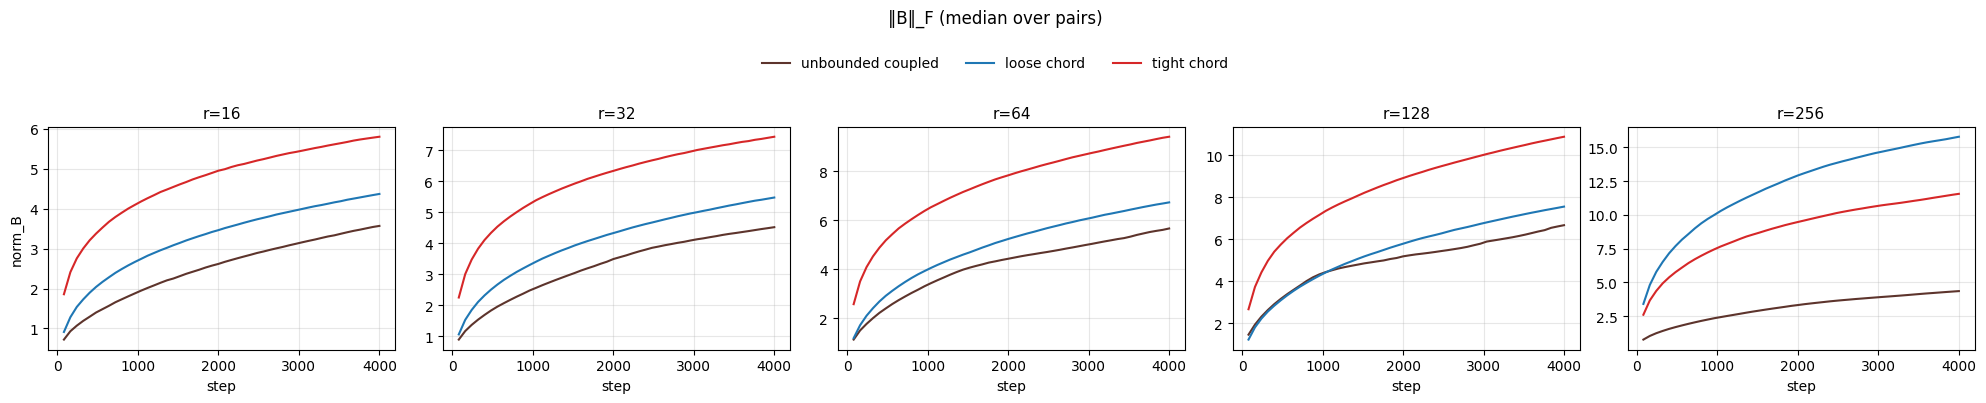

In [93]:
def _plot_normA(ax, d, m):
    s, v = diag_trajectory(d, 'norm_A_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_normA, '‖A‖_F (median over pairs)', 'norm_A', sharey=False)

def _plot_normB(ax, d, m):
    s, v = diag_trajectory(d, 'norm_B_median')
    if len(s):
        ax.plot(s, v, color=METHOD_COLOR[m], label=m, lw=1.5)

faceted_plot(_plot_normB, '‖B‖_F (median over pairs)', 'norm_B', sharey=False)